# First Classification attempt - Problem baseline

I'm going to use machine learning models to predict the injury status of the players with the data we have.
I do not expect to get good results, but I want to get a baseline to compare after improving the data and trying more advance techniques and models.

I'm going to use the following models:
- Logistic Regression
- Random Forest
- XGBoost
- Support Vector Machines

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
)

import xgboost as xgb

import joblib
import json
from datetime import datetime
import os

import core.constants as c

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
X = pd.read_csv(c.RICKD_BASELINE_X_FILE, index_col=0)
Y = pd.read_csv(c.RICKD_BASELINE_Y_FILE, index_col=0)

print(f"X Dataset shape: {X.shape}")
print(f"X Columns: {list(X.columns)}")
display(X.head())

print(f"Y Dataset shape: {Y.shape}")
print(f"Y Columns: {list(Y.columns)}")
display(Y.head())

# Class imbalance
print(f"Class distribution: {Y['is_injured'].value_counts()}")
print(f"Class distribution: {Y['is_injured'].value_counts(normalize=True)}")

X Dataset shape: (1832, 93)
X Columns: ['speed_r', 'age', 'Height', 'Weight', 'YrsRunning', 'NumRaces', 'l_step_width', 'l_stride_rate', 'l_stride_length', 'l_swing_time', 'l_stance_time', 'l_pelvis_peak_drop_angle', 'l_pelvis_drop_excursion', 'l_ankle_df_peak_angle', 'l_ankle_eve_peak_angle', 'l_ankle_eve_percent_stance', 'l_ankle_eve_excursion', 'l_ankle_rot_peak_angle', 'l_ankle_rot_excursion', 'l_knee_flex_peak_angle', 'l_knee_add_peak_angle', 'l_knee_add_excursion', 'l_knee_abd_peak_angle', 'l_knee_abd_excursion', 'l_knee_rot_peak_angle', 'l_knee_rot_excursion', 'l_hip_ext_peak_angle', 'l_hip_add_peak_angle', 'l_hip_add_excursion', 'l_hip_rot_peak_angle', 'l_hip_rot_excursion', 'l_foot_prog_angle', 'l_foot_ang_at_hs', 'l_mhw_exc_from_to', 'l_ankle_eve_peak_vel', 'l_ankle_rot_peak_vel', 'l_knee_abd_peak_vel', 'l_knee_add_peak_vel', 'l_hip_abd_peak_vel', 'l_knee_rot_peak_vel', 'l_hip_rot_peak_vel', 'l_pronation_onset', 'l_pronation_offset', 'l_peak_hip_add_velocity', 'l_peak_pelvic_

,speed_r,age,Height,Weight,YrsRunning,NumRaces,l_step_width,l_stride_rate,l_stride_length,l_swing_time,...,r_peak_hip_add_velocity,r_peak_pelvic_drop_velocity,r_vertical_oscillation,Gender_female,Gender_male,DominantLeg_ambidextrous,DominantLeg_left,DominantLeg_right,Level_competitive,Level_recreational
id,,,,,,,,,,,,,,,,,,,,,
100433_20101005t132240,-2.406926,1.231321,-11.741497,-5.056746,0.578686,-0.393107,-0.307243,0.000986,-2.622528,-0.338913,...,-1.743700,0.239058,-1.935588,False,False,False,False,False,False,True
100434_20101117t132240,-1.095016,1.066816,-11.741497,-5.056746,1.308477,-0.393107,-1.831460,0.886585,-1.458975,-0.466027,...,0.764244,-0.390267,-1.344740,True,False,False,False,False,False,True
100537_20120703t102550,-1.325076,-3.128072,0.097259,-0.179365,-0.568129,-0.393107,-0.037324,-0.643565,-1.241474,-0.084685,...,2.255015,0.604189,-0.284941,True,False,False,False,True,False,True
100560_20120717t103748,-0.215279,-0.413733,0.521293,0.931754,-0.776641,-0.393107,0.677045,-1.610390,0.439240,-1.165155,...,3.526927,-1.746297,1.346349,True,False,False,False,True,False,True
101481_20120717t105021,-0.282875,-0.495986,0.316116,-0.828721,-0.776641,-0.393107,0.104643,-0.746010,-0.016982,-0.148242,...,0.475554,1.000454,0.657459,True,False,False,False,False,False,False


Y Dataset shape: (1832, 13)
Y Columns: ['injury_severity_code', 'injury_severity_value', 'injury_code', 'injury2_code', 'injury_desc', 'injury2_desc', 'injury_name', 'injury2_name', 'injured_joint_code', 'injured_joint2_code', 'injured_side_code', 'injured_side2_code', 'is_injured']


,injury_severity_code,injury_severity_value,injury_code,injury2_code,injury_desc,injury2_desc,injury_name,injury2_name,injured_joint_code,injured_joint2_code,injured_side_code,injured_side2_code,is_injured
id,,,,,,,,,,,,,
100433_20101005t132240,volume_intensity,2.0,pain,no_injury,General sensation of discomfort without speci...,No injury has been diagnosed.,pain,no injury,knee,no_injury,right,right,1
100434_20101117t132240,volume_intensity,2.0,disc_dege,no_injury,Breakdown and gradual loss of spinal disc cush...,No injury has been diagnosed.,disc degeneration,no injury,lumbar_spine,no_injury,bilateral,right,1
100537_20120703t102550,missed_2_workouts,3.0,pain,no_injury,General sensation of discomfort without speci...,No injury has been diagnosed.,pain,no injury,hip_pelvis,no_injury,right,right,1
100560_20120717t103748,no_injury,0.0,no_injury,no_injury,No injury has been diagnosed.,No injury has been diagnosed.,no injury,no injury,no_injury,no_injury,right,right,0
101481_20120717t105021,no_injury,0.0,no_injury,no_injury,No injury has been diagnosed.,No injury has been diagnosed.,no injury,no injury,no_injury,no_injury,no_injury,no_injury,0


Class distribution: is_injured
1    1167
0     665
Name: count, dtype: int64
Class distribution: is_injured
1    0.637009
0    0.362991
Name: proportion, dtype: float64


In [3]:
y = Y["is_injured"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 1465 samples
Test set: 367 samples


## Model configuration

In [4]:
models_config = {
    'Logistic Regression': {
        'pipeline': Pipeline([
            ('classifier', LogisticRegression(random_state=RANDOM_STATE))
        ]),
        'param_grid': {
            'classifier__C': [0.1, 1, 10, 100],
            'classifier__penalty': ['l1', 'l2'],
            'classifier__solver': ['liblinear']
        }
    },
    
    'Random Forest': {
        'pipeline': Pipeline([
            ('classifier', RandomForestClassifier(random_state=RANDOM_STATE))
        ]),
        'param_grid': {
            'classifier__n_estimators': [50, 100, 200],
            'classifier__max_depth': [None, 10, 20, 30],
            'classifier__min_samples_split': [2, 5, 10],
            'classifier__min_samples_leaf': [1, 2, 4]
        }
    },
    
    'XGBoost': {
        'pipeline': Pipeline([
            ('classifier', xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'))
        ]),
        'param_grid': {
            'classifier__n_estimators': [50, 100, 200],
            'classifier__max_depth': [3, 6, 9],
            'classifier__learning_rate': [0.01, 0.1, 0.2],
            'classifier__subsample': [0.8, 0.9, 1.0]
        }
    },
    
    'SVM': {
        'pipeline': Pipeline([
            ('classifier', SVC(random_state=RANDOM_STATE, probability=True))
        ]),
        'param_grid': {
            'classifier__C': [0.1, 1, 10],
            'classifier__kernel': ['rbf', 'linear'],
            'classifier__gamma': ['scale', 'auto', 0.1, 0.01]
        }
    }
}


## Train Models with Grid Search

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
trained_models = {}
results = {}

for model_name, config in models_config.items():
    print('\n' + '='*30)
    print(f"Training {model_name}...")
    print('='*30)
    
    grid_search = GridSearchCV(
        estimator=config['pipeline'],
        param_grid=config['param_grid'],
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    trained_models[model_name] = grid_search
    results[model_name] = {
        'best_score': grid_search.best_score_,
        'best_params': grid_search.best_params_,
        'cv_results': grid_search.cv_results_
    }
    
    print(f"Best CV Score: {grid_search.best_score_:.4f}")
    print(f"Best Parameters: {grid_search.best_params_}")
    
    y_pred = grid_search.predict(X_test)
    y_pred_proba = grid_search.predict_proba(X_test)
    
    test_accuracy = accuracy_score(y_test, y_pred)
    test_precision = precision_score(y_test, y_pred, average='weighted')
    test_recall = recall_score(y_test, y_pred, average='weighted')
    test_f1 = f1_score(y_test, y_pred, average='weighted')
    test_roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
    
    results[model_name].update({
        'test_accuracy': test_accuracy,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_f1': test_f1,
        'test_roc_auc': test_roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    })
    
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Test Precision: {test_precision:.4f}")
    print(f"Test Recall: {test_recall:.4f}")
    print(f"Test F1-Score: {test_f1:.4f}")
    print(f"Test ROC AUC: {test_roc_auc:.4f}")


Training Logistic Regression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best CV Score: 0.7583
Best Parameters: {'classifier__C': 1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Test Accuracy: 0.7766
Test Precision: 0.7793
Test Recall: 0.7766
Test F1-Score: 0.7632
Test ROC AUC: 0.7818

Training Random Forest...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best CV Score: 0.8180
Best Parameters: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Test Accuracy: 0.7820
Test Precision: 0.8179
Test Recall: 0.7820
Test F1-Score: 0.7561
Test ROC AUC: 0.7763

Training XGBoost...
Fitting 5 folds for each of 81 candidates, totalling 405 fits


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best CV Score: 0.8171
Best Parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 6, 'classifier__n_estimators': 200, 'classifier__subsample': 0.9}
Test Accuracy: 0.8065
Test Precision: 0.8139
Test Recall: 0.8065
Test F1-Score: 0.7953
Test ROC AUC: 0.8126

Training SVM...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best CV Score: 0.8162
Best Parameters: {'classifier__C': 10, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
Test Accuracy: 0.7738
Test Precision: 0.7697
Test Recall: 0.7738
Test F1-Score: 0.7696
Test ROC AUC: 0.8219


In [7]:
# Use pydantic for serialization of results into JSON that is compatible with numpy types.

from pydantic import BaseModel
from typing import Any, List

class ResultModel(BaseModel):
    model_name: str
    test_accuracy: float
    test_precision: float
    test_recall: float
    test_f1: float
    test_roc_auc: float
    y_pred: Any
    y_pred_proba: Any
    best_parameters: Any
    best_score: float

    class Config:
        arbitrary_types_allowed = True
        json_encoders = {
            # Handles numpy types and arrays
            # (np types are not imported here, but pydantic will use .tolist() if present)
        }

class ResultsModel(BaseModel):
    results: List[ResultModel]

In [9]:
target_folder = os.path.join(c.RICKD_MODELS_FOLDER, "baselineV1")
os.makedirs(target_folder, exist_ok=True)

# Save trained models
model_filenames = {}
for model_name, result in results.items():
    model_obj = trained_models[model_name]
    filename = f"{model_name.lower().replace(' ', '_')}_model.pkl"
    model_file = os.path.join(target_folder, filename)
    joblib.dump(model_obj, model_file)
    model_filenames[model_name] = model_file
    print(f"Model '{model_name}' saved to: {model_file}")

# Save results:
results_list = []
for model_name, result in results.items():
    gridsearch = trained_models[model_name]
    best_params = getattr(gridsearch, "best_params_", None)
    best_score = getattr(gridsearch, "best_score_", None)
    results_list.append(
        ResultModel(
            model_name=model_name,
            test_accuracy=float(result['test_accuracy']),
            test_precision=float(result['test_precision']),
            test_recall=float(result['test_recall']),
            test_f1=float(result['test_f1']),
            test_roc_auc=float(result['test_roc_auc']),
            y_pred=result['y_pred'].tolist(),
            y_pred_proba=result['y_pred_proba'].tolist(),
            best_parameters=best_params,
            best_score=float(best_score) if best_score is not None else None,
        )
    )

results_model = ResultsModel(results=results_list)

results_json_filename = os.path.join(target_folder, "results_summary.json")
with open(results_json_filename, "w") as f:
    f.write(results_model.model_dump_json(indent=2))

print(f"Results summary saved to: {results_json_filename}")

Model 'Logistic Regression' saved to: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/baselineV1/logistic_regression_model.pkl
Model 'Random Forest' saved to: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/baselineV1/random_forest_model.pkl
Model 'XGBoost' saved to: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/baselineV1/xgboost_model.pkl
Model 'SVM' saved to: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/baselineV1/svm_model.pkl
Results summary saved to: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/baselineV1/results_summary.json


In [13]:
# Load results from JSON
with open(results_json_filename, "r") as f:
    results_json = f.read()
results_model_loaded = ResultsModel.model_validate_json(results_json)
results_loaded = {}
for result in results_model_loaded.results:
    results_loaded[result.model_name] = {
        'test_accuracy': result.test_accuracy,
        'test_precision': result.test_precision,
        'test_recall': result.test_recall,
        'test_f1': result.test_f1,
        'test_roc_auc': result.test_roc_auc,
        'y_pred': np.array(result.y_pred),
        'y_pred_proba': np.array(result.y_pred_proba),
        'best_parameters': result.best_parameters,
        'best_score': result.best_score,
    }

# Load trained models from pickle files
trained_models_loaded = {}
for model_name, model_file in model_filenames.items():
    trained_models_loaded[model_name] = joblib.load(model_file)


results = results_loaded
trained_models = trained_models_loaded


## Analysis of Models

Model Performance Comparison by Test ROC AUC:
                 Model  Test ROC AUC  Test Accuracy  Test Precision  \
3                  SVM        0.8219         0.7738          0.7697   
2              XGBoost        0.8126         0.8065          0.8139   
0  Logistic Regression        0.7818         0.7766          0.7793   
1        Random Forest        0.7763         0.7820          0.8179   

   Test Recall  Test F1-Score  
3       0.7738         0.7696  
2       0.8065         0.7953  
0       0.7766         0.7632  
1       0.7820         0.7561  

Best performing model: SVM
Best Test ROC AUC Score: 0.8219


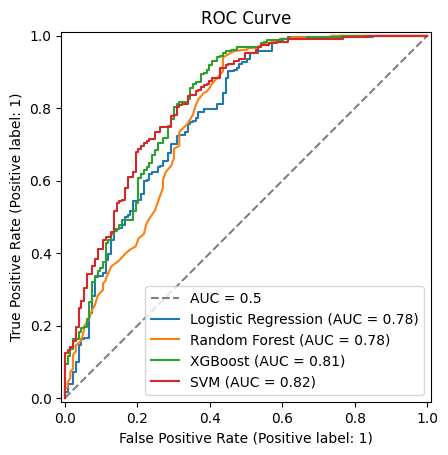

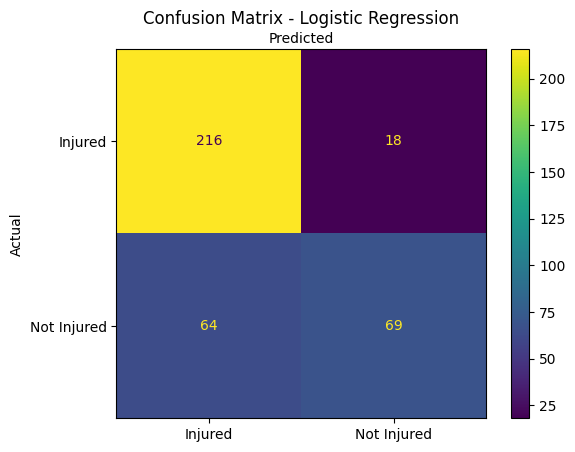

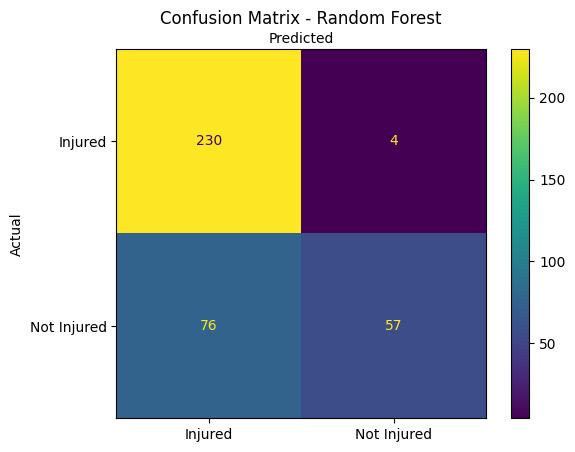

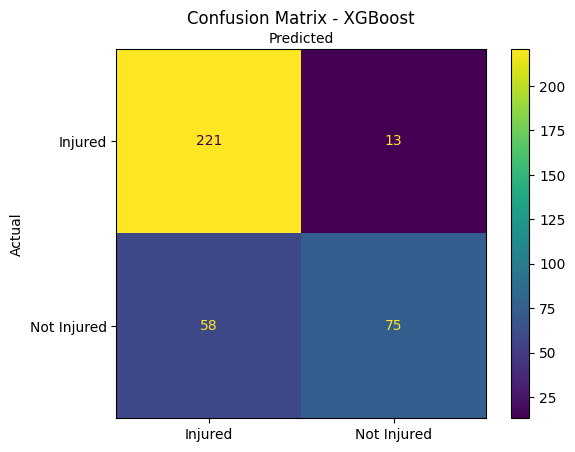

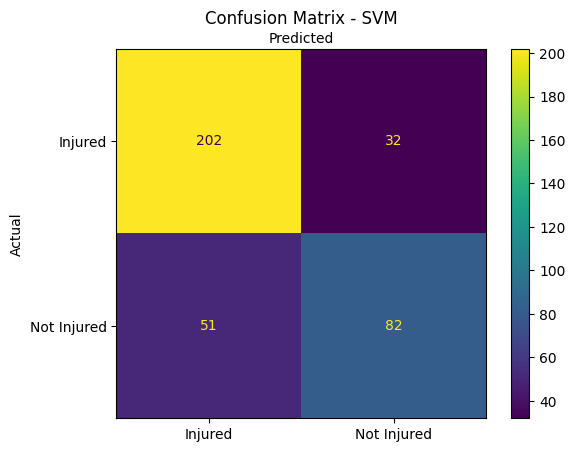

In [14]:
comparison_data = []
ax = plt.gca()

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='AUC = 0.5')

for model_name, result in results.items():
    comparison_data.append({
        'Model': model_name,
        'Test ROC AUC': result['test_roc_auc'],
        'Test Accuracy': result['test_accuracy'],
        'Test Precision': result['test_precision'],
        'Test Recall': result['test_recall'],
        'Test F1-Score': result['test_f1'],
    })
    roc_disp = RocCurveDisplay.from_predictions(
        y_test, 
        result['y_pred_proba'][:, 1], 
        name=model_name,
        ax=ax,
    )
roc_disp.ax_.set_title('ROC Curve')

for model_name, result in results.items():
    class_labels = ['Injured', 'Not Injured']
    cm_disp = ConfusionMatrixDisplay.from_predictions(
        y_test, 
        result['y_pred'], 
        display_labels=class_labels,
        labels=[1, 0]
    )
    cm_disp.ax_.xaxis.set_label_position('top')
    cm_disp.ax_.xaxis.set_label_text('Predicted')
    cm_disp.ax_.yaxis.set_label_text('Actual')
    cm_disp.ax_.set_title(f'Confusion Matrix - {model_name}')

PRIMARY_METRIC = 'Test ROC AUC'
comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values(PRIMARY_METRIC, ascending=False)

print(f"Model Performance Comparison by {PRIMARY_METRIC}:")
print('='*50)
print(comparison_df.round(4))

best_model_name = comparison_df.iloc[0]['Model']
print(f"\nBest performing model: {best_model_name}")
print(f"Best {PRIMARY_METRIC} Score: {comparison_df.iloc[0][PRIMARY_METRIC]:.4f}")

In [ ]:
# Feature importance for all models
from sklearn.inspection import permutation_importance

def get_feature_importance(model_name, model, X_data, y_data):
    """
    Extract feature importance for different model types
    """
    classifier = model.best_estimator_.named_steps['classifier']
    feature_names = X_data.columns
    
    if hasattr(classifier, 'feature_importances_'):
        # Tree-based models (Random Forest, XGBoost)
        importance_values = classifier.feature_importances_
        importance_type = 'Built-in'
        
    elif hasattr(classifier, 'coef_'):
        # Linear models (Logistic Regression)
        importance_values = np.abs(classifier.coef_[0])  # Use absolute values of coefficients
        importance_type = 'Coefficient Magnitude'
        
    else:
        # Models without built-in importance (SVM) - use permutation importance
        print(f"Computing permutation importance for {model_name}...")
        perm_importance = permutation_importance(
            model, X_data, y_data, 
            n_repeats=10, 
            random_state=RANDOM_STATE,
            scoring='roc_auc'
        )
        importance_values = perm_importance.importances_mean
        importance_type = 'Permutation'
    
    # Create dataframe
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importance_values,
        'importance_type': importance_type
    }).sort_values('importance', ascending=False)
    
    return importance_df

# Calculate feature importance for all models
all_feature_importance = {}
feature_rankings = {}

print("Computing feature importance for all models...")
print("=" * 60)

for model_name, model in trained_models.items():
    print(f"\nAnalyzing {model_name}...")
    
    # Get feature importance
    importance_df = get_feature_importance(model_name, model, X_test, y_test)
    all_feature_importance[model_name] = importance_df
    
    # Store rankings for comparison
    feature_rankings[model_name] = importance_df['feature'].tolist()
    
    print(f"Feature importance type: {importance_df['importance_type'].iloc[0]}")
    print(f"Top 5 features: {', '.join(importance_df['feature'].head(5).tolist())}")

print(f"\nFeature importance analysis completed!")
print("=" * 60)

Computing feature importance for all models...

Analyzing Logistic Regression...
Feature importance type: Coefficient Magnitude
Top 5 features: Level_competitive, Level_recreational, DominantLeg_left, DominantLeg_right, l_hip_rot_peak_angle

Analyzing Random Forest...
Feature importance type: Built-in
Top 5 features: YrsRunning, speed_r, Level_recreational, age, DominantLeg_right

Analyzing XGBoost...
Feature importance type: Built-in
Top 5 features: Level_competitive, Level_recreational, YrsRunning, NumRaces, r_pronation_offset

Analyzing SVM...
Computing permutation importance for SVM...
Feature importance type: Permutation
Top 5 features: l_knee_flex_peak_angle, Level_competitive, Level_recreational, r_knee_flex_peak_angle, r_foot_prog_angle

Feature importance analysis completed!


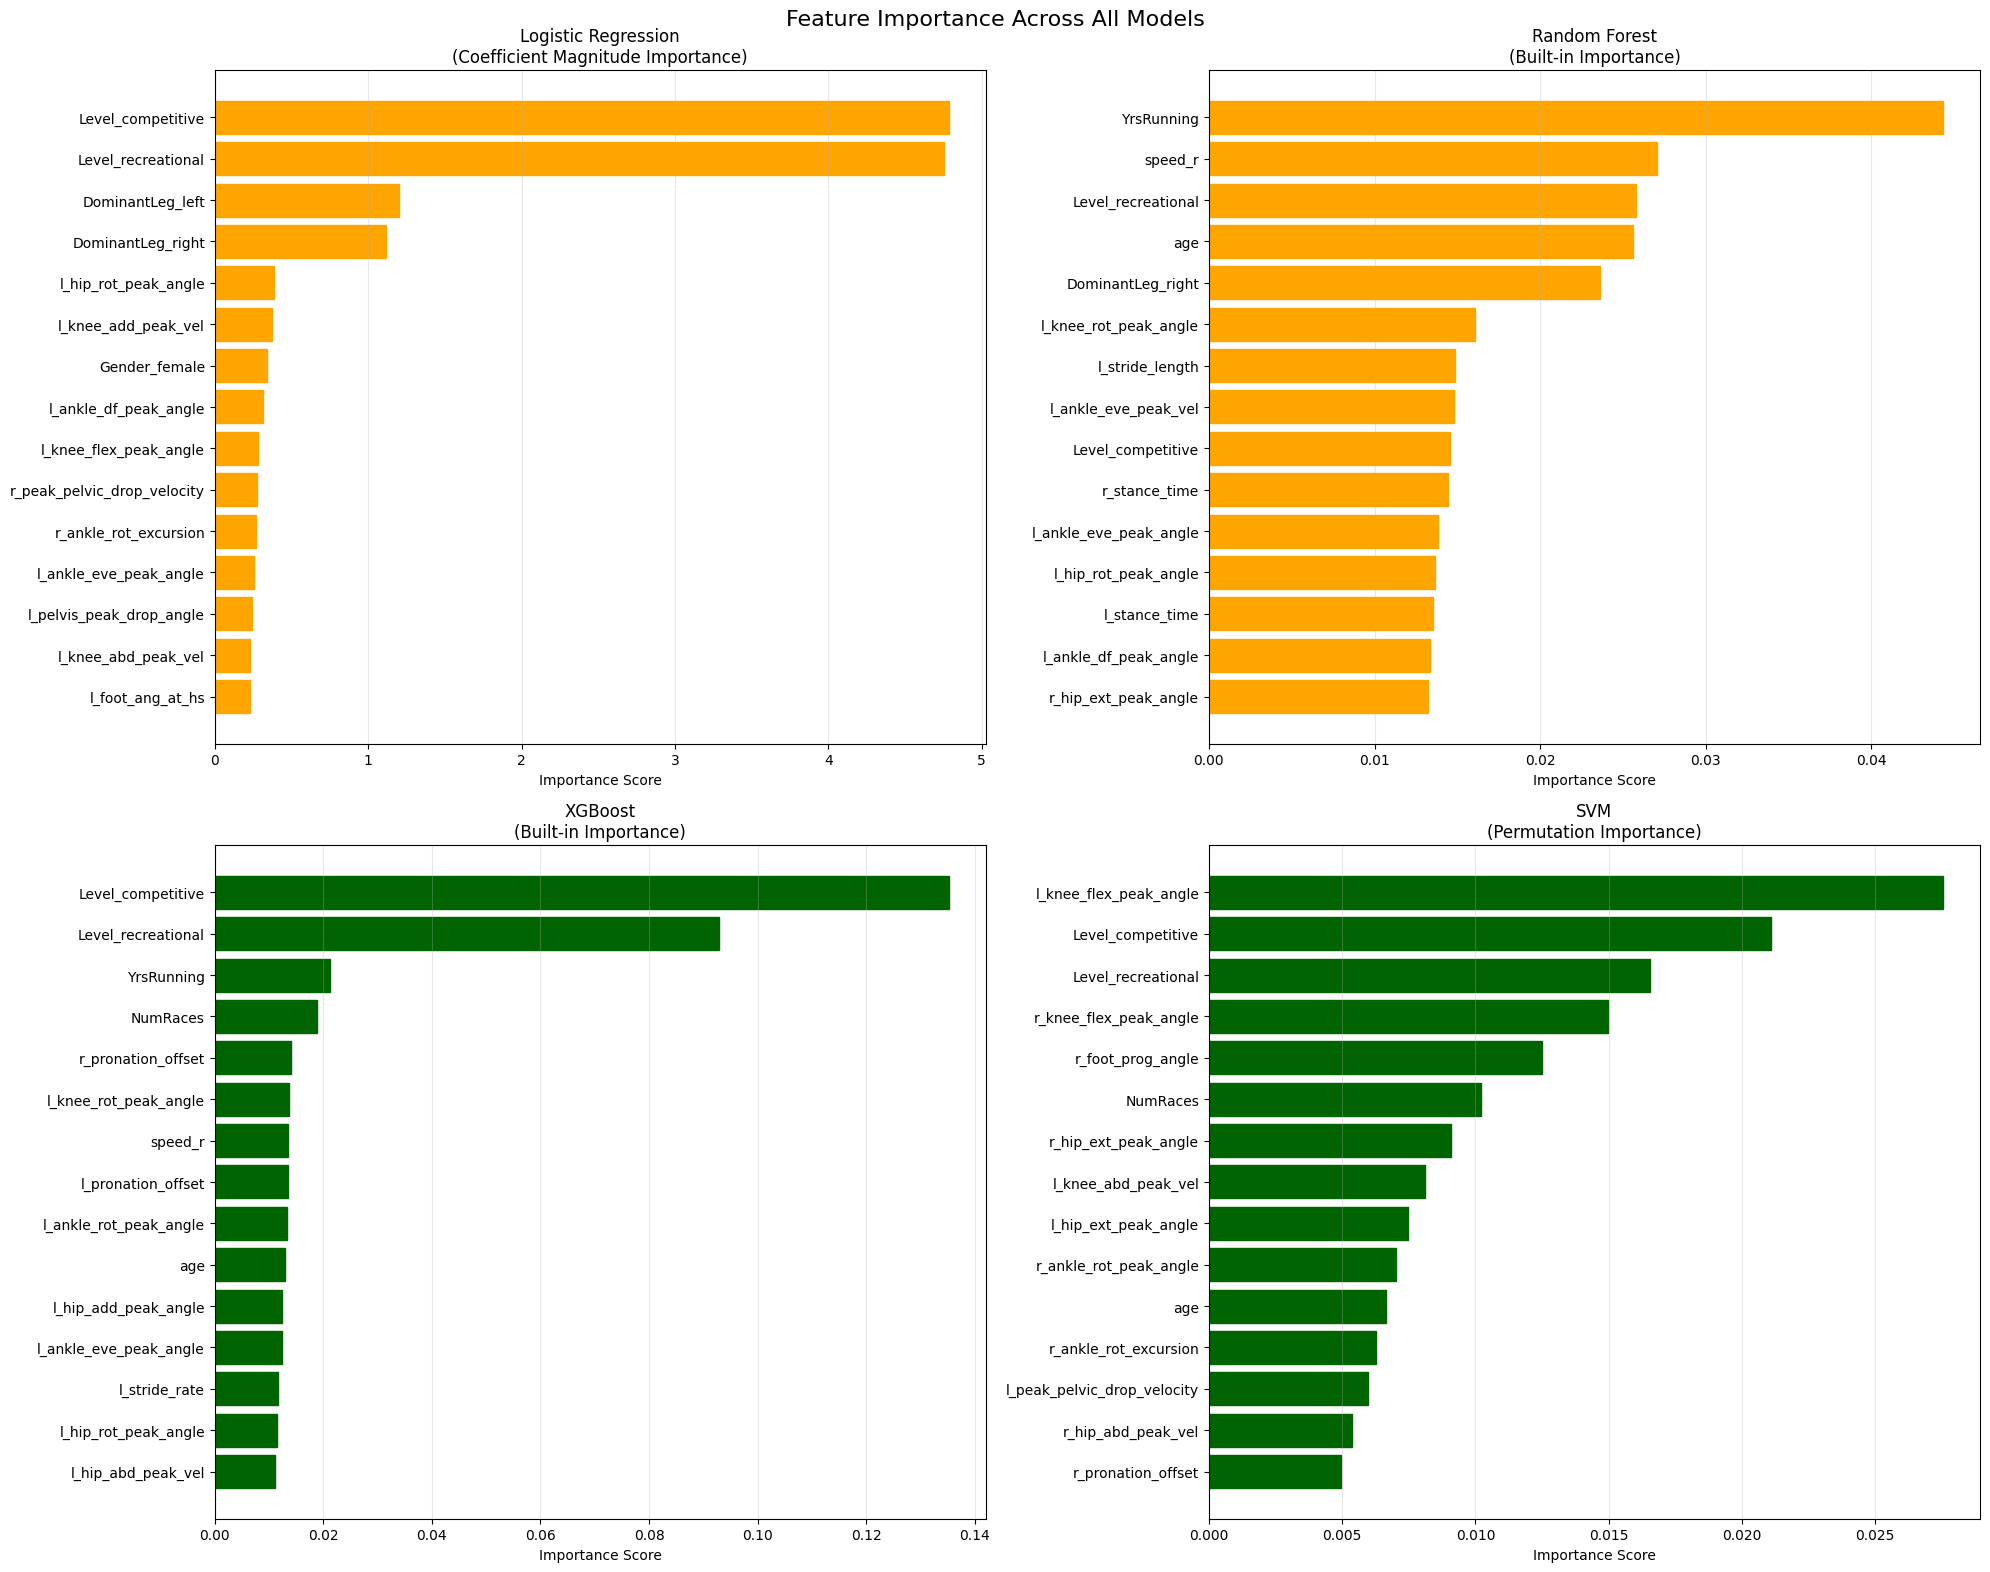


TOP 10 FEATURES COMPARISON ACROSS ALL MODELS

Logistic Regression (ROC-AUC: 0.7818):
--------------------------------------------------
 1. Level_competitive                   4.7869
 2. Level_recreational                  4.7568
 3. DominantLeg_left                    1.1990
 4. DominantLeg_right                   1.1175
 5. l_hip_rot_peak_angle                0.3885
 6. l_knee_add_peak_vel                 0.3742
 7. Gender_female                       0.3412
 8. l_ankle_df_peak_angle               0.3133
 9. l_knee_flex_peak_angle              0.2809
10. r_peak_pelvic_drop_velocity         0.2773

Random Forest (ROC-AUC: 0.7763):
--------------------------------------------------
 1. YrsRunning                          0.0444
 2. speed_r                             0.0270
 3. Level_recreational                  0.0258
 4. age                                 0.0256
 5. DominantLeg_right                   0.0236
 6. l_knee_rot_peak_angle               0.0161
 7. l_stride_length       

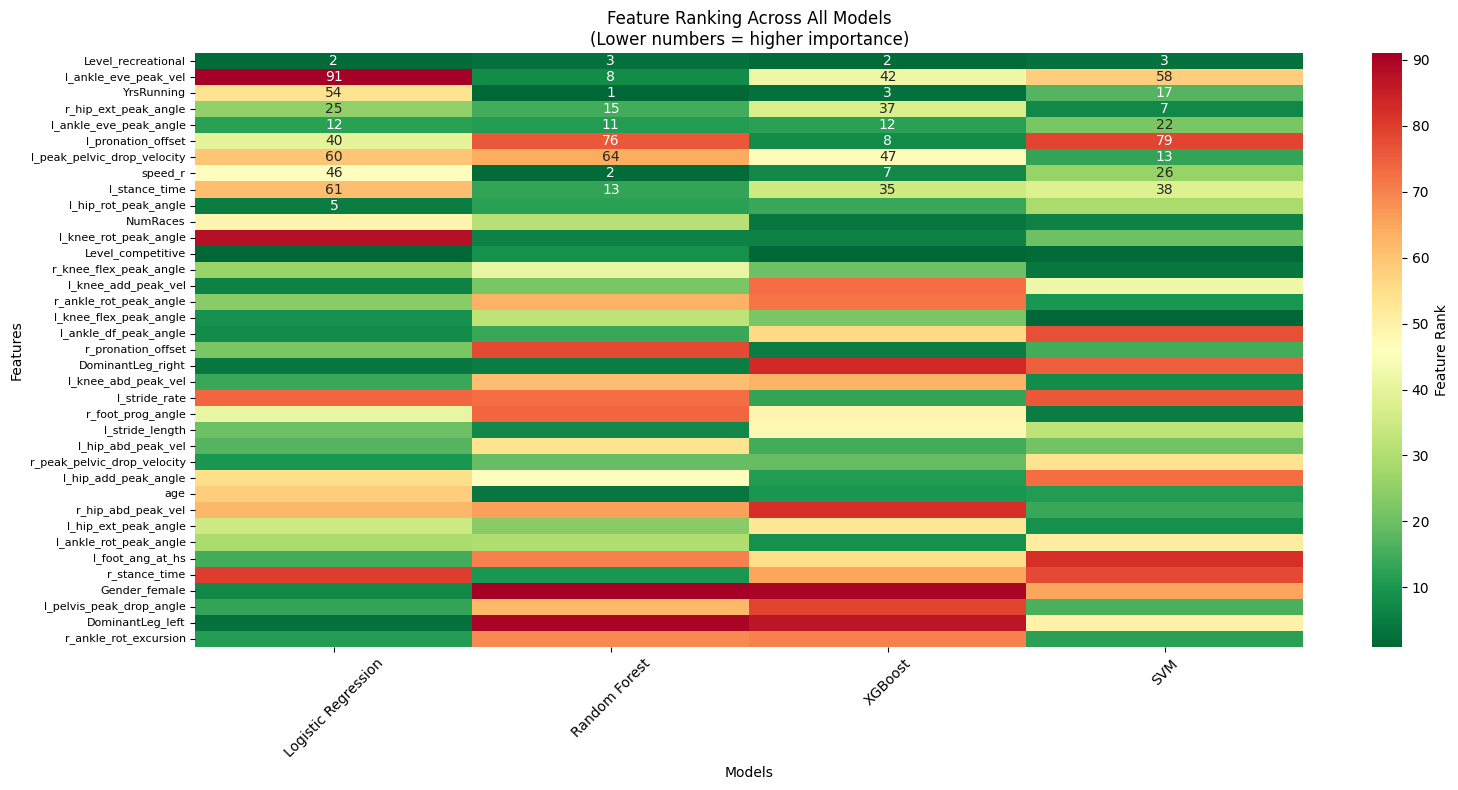


Heatmap shows ranking of 37 most important features across all models.
Lower numbers (green) indicate higher importance, higher numbers (red) indicate lower importance.


In [ ]:
# Comprehensive Feature Importance Visualization and Analysis

# 1. Individual feature importance plots for each model
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.ravel()

for idx, (model_name, importance_df) in enumerate(all_feature_importance.items()):
    ax = axes[idx]
    
    # Plot top 15 features for each model
    top_features = importance_df.head(15)
    bars = ax.barh(range(len(top_features)), top_features['importance'])
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['feature'], fontsize=10)
    ax.set_xlabel('Importance Score')
    ax.set_title(f'{model_name}\n({top_features["importance_type"].iloc[0]} Importance)', fontsize=12)
    ax.invert_yaxis()
    
    # Color bars based on performance
    model_auc = results[model_name]['test_roc_auc']
    if model_auc > 0.8:
        color = 'darkgreen'
    elif model_auc > 0.77:
        color = 'orange'
    else:
        color = 'lightcoral'
    
    for bar in bars:
        bar.set_color(color)
    
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Feature Importance Across All Models', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

# 2. Top features comparison across models
print("\n" + "="*80)
print("TOP 10 FEATURES COMPARISON ACROSS ALL MODELS")
print("="*80)

top_n = 10
for model_name, importance_df in all_feature_importance.items():
    print(f"\n{model_name} (ROC-AUC: {results[model_name]['test_roc_auc']:.4f}):")
    print("-" * 50)
    top_features = importance_df.head(top_n)
    for i, (_, row) in enumerate(top_features.iterrows()):
        print(f"{i+1:2d}. {row['feature']:35s} {row['importance']:.4f}")

# 3. Feature frequency analysis - how often features appear in top rankings
print(f"\n" + "="*80)
print("FEATURE FREQUENCY IN TOP RANKINGS ANALYSIS")
print("="*80)

# Count how often each feature appears in top N across all models
top_n_values = [5, 10, 15, 20]
feature_frequency = {}

for top_n in top_n_values:
    feature_count = {}
    
    for model_name, importance_df in all_feature_importance.items():
        top_features = importance_df.head(top_n)['feature'].tolist()
        for feature in top_features:
            feature_count[feature] = feature_count.get(feature, 0) + 1
    
    # Sort by frequency
    feature_frequency[top_n] = sorted(feature_count.items(), key=lambda x: x[1], reverse=True)
    
    print(f"\nFeatures appearing most frequently in Top {top_n}:")
    print("-" * 50)
    for feature, count in feature_frequency[top_n][:15]:  # Show top 15
        percentage = (count / len(trained_models)) * 100
        print(f"{feature:35s} {count}/4 models ({percentage:5.1f}%)")

# 4. Consensus features - features that appear in top rankings across multiple models
print(f"\n" + "="*80)
print("CONSENSUS IMPORTANT FEATURES")
print("="*80)

# Features that appear in top 10 of at least 3 models
consensus_features = []
for feature, count in feature_frequency[10]:
    if count >= 3:  # Appears in at least 3 out of 4 models
        consensus_features.append(feature)

print(f"\nFeatures in Top 10 of at least 3 models ({len(consensus_features)} features):")
print("-" * 50)
for feature in consensus_features:
    print(f"• {feature}")

# 5. Create a heatmap of feature rankings across models
print(f"\n" + "="*80)
print("FEATURE RANKING HEATMAP")
print("="*80)

# Get top 20 most frequently appearing features across all models
all_important_features = set()
for importance_df in all_feature_importance.values():
    all_important_features.update(importance_df.head(20)['feature'].tolist())

# Create ranking matrix
ranking_matrix = []
feature_list = list(all_important_features)

for model_name in trained_models.keys():
    model_rankings = []
    importance_df = all_feature_importance[model_name]
    feature_to_rank = {feature: idx + 1 for idx, feature in enumerate(importance_df['feature'])}
    
    for feature in feature_list:
        rank = feature_to_rank.get(feature, len(importance_df) + 1)  # If not in top, assign lowest rank
        model_rankings.append(rank)
    
    ranking_matrix.append(model_rankings)

# Create DataFrame for heatmap
ranking_df = pd.DataFrame(ranking_matrix, 
                         index=list(trained_models.keys()), 
                         columns=feature_list)

# Plot heatmap (show only features that appear in top 15 of at least one model)
frequently_important = []
for feature in feature_list:
    if any(ranking_df[feature] <= 15):
        frequently_important.append(feature)

plt.figure(figsize=(16, 8))
heatmap_data = ranking_df[frequently_important].T
sns.heatmap(heatmap_data, 
            annot=True, 
            fmt='d', 
            cmap='RdYlGn_r',  # Red = high rank (less important), Green = low rank (more important)
            cbar_kws={'label': 'Feature Rank'},
            xticklabels=True,
            yticklabels=True)
plt.title('Feature Ranking Across All Models\n(Lower numbers = higher importance)')
plt.xlabel('Models')
plt.ylabel('Features')
plt.xticks(rotation=45)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

print(f"\nHeatmap shows ranking of {len(frequently_important)} most important features across all models.")
print("Lower numbers (green) indicate higher importance, higher numbers (red) indicate lower importance.")


# Detailed Feature Analysis and Insights

# 6. Feature importance stability across models
print("\n" + "="*80)
print("FEATURE IMPORTANCE STABILITY ANALYSIS")
print("="*80)

# Calculate coefficient of variation for top features across models
def calculate_feature_stability():
    """Calculate how stable feature rankings are across models"""
    stability_scores = {}
    
    # Get features that appear in top 20 of at least 2 models
    candidate_features = set()
    for importance_df in all_feature_importance.values():
        candidate_features.update(importance_df.head(20)['feature'].tolist())
    
    for feature in candidate_features:
        ranks = []
        for model_name, importance_df in all_feature_importance.items():
            feature_to_rank = {f: idx + 1 for idx, f in enumerate(importance_df['feature'])}
            rank = feature_to_rank.get(feature, len(importance_df) + 1)
            ranks.append(rank)
        
        # Calculate coefficient of variation (lower = more stable)
        if len(ranks) > 1:
            mean_rank = np.mean(ranks)
            std_rank = np.std(ranks)
            cv = std_rank / mean_rank if mean_rank > 0 else float('inf')
            stability_scores[feature] = {
                'mean_rank': mean_rank,
                'std_rank': std_rank,
                'cv': cv,
                'ranks': ranks
            }
    
    return stability_scores

stability_scores = calculate_feature_stability()

# Sort by stability (lowest coefficient of variation)
stable_features = sorted(stability_scores.items(), key=lambda x: x[1]['cv'])

print("\nMost STABLE features across models (low coefficient of variation):")
print("-" * 60)
for i, (feature, stats) in enumerate(stable_features[:15]):
    print(f"{i+1:2d}. {feature:35s} Mean Rank: {stats['mean_rank']:5.1f}, CV: {stats['cv']:.3f}")

print("\nMost UNSTABLE features across models (high coefficient of variation):")
print("-" * 60)
for i, (feature, stats) in enumerate(stable_features[-10:]):
    print(f"{i+1:2d}. {feature:35s} Mean Rank: {stats['mean_rank']:5.1f}, CV: {stats['cv']:.3f}")

# 7. Feature category analysis
print(f"\n" + "="*80)
print("FEATURE CATEGORY ANALYSIS")
print("="*80)

def categorize_features(feature_name):
    """Categorize features by body part and measurement type"""
    if 'age' in feature_name.lower() or 'height' in feature_name.lower() or 'weight' in feature_name.lower():
        return 'Demographics'
    elif 'speed' in feature_name.lower() or 'yrs' in feature_name.lower() or 'race' in feature_name.lower():
        return 'Experience/Performance'
    elif 'gender' in feature_name.lower():
        return 'Demographics'
    elif feature_name.startswith('l_'):
        body_part = 'Left ' + feature_name.split('_')[1].title()
        return body_part
    elif feature_name.startswith('r_'):
        body_part = 'Right ' + feature_name.split('_')[1].title()
        return body_part
    else:
        return 'Other'

# Categorize consensus features
consensus_categories = {}
for feature in consensus_features:
    category = categorize_features(feature)
    if category not in consensus_categories:
        consensus_categories[category] = []
    consensus_categories[category].append(feature)

print(f"\nConsensus features by body part/category:")
print("-" * 50)
for category, features in sorted(consensus_categories.items()):
    print(f"\n{category}:")
    for feature in features:
        print(f"  • {feature}")

# 8. Create summary statistics
print(f"\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

summary_stats = {
    'Total Features': X.shape[1],
    'Models Analyzed': len(trained_models),
    'Consensus Features (Top 10, ≥3 models)': len(consensus_features),
    'Most Stable Feature': stable_features[0][0] if stable_features else 'N/A',
    'Best Performing Model': best_model_name,
    'Best Model ROC-AUC': results[best_model_name]['test_roc_auc']
}

for key, value in summary_stats.items():
    if isinstance(value, float):
        print(f"{key:35s}: {value:.4f}")
    else:
        print(f"{key:35s}: {value}")

# 9. Feature recommendations
print(f"\n" + "="*80)
print("FEATURE IMPORTANCE RECOMMENDATIONS")
print("="*80)

print("\n🎯 KEY FINDINGS:")
print("-" * 40)
print(f"1. {len(consensus_features)} features consistently important across models")
print(f"2. Most stable feature: {stable_features[0][0]}")
print(f"3. Best performing model: {best_model_name} (ROC-AUC: {results[best_model_name]['test_roc_auc']:.4f})")

print("\n📊 RECOMMENDED FEATURE SET:")
print("-" * 40)
print("For future model development, prioritize these consensus features:")
for i, feature in enumerate(consensus_features[:10], 1):
    print(f"{i:2d}. {feature}")

print(f"\n💡 INSIGHTS FOR MODEL IMPROVEMENT:")
print("-" * 40)
print("1. Focus on biomechanical features that show consensus across models")
print("2. Consider feature engineering based on stable, important features")
print("3. The high variability in some features suggests potential for ensemble methods")
print("4. Investigate why certain features are model-specific vs. universally important")

## Save models

Podria una linea de TFM ser:
- Partir de estos resultados base y investigar como podemos mejorar las capacidades de predicción?